# Linear discriminant analysis

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Understand and be able to implement and use LDA;
- Understand assumptions and limitations of LDA;
- Be able to provide solution to common issues of LDA.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

## Exercise 1: train LDA
In the first exercise, you will implement LDA from scratch using plain numpy. We will later train and test it with the Iris dataset, and compare it to the implementation from the "sklearn" library.
1. Provide the equations to train the weights and bias of LDA in LaTeX. (You can use LaTeX in Markdown by surrounding your formula with \$\$); 
1. Write the function `train_lda(X, y)` that accepts the data $X$ of dimensionality $N_{samples} \times D_{features}$ and the labels $y$, a vector of $N_{samples}$ containing integer class labels. The function should output the weights and bias. Note, we assume a binary classification problem.

**The equations to train the weights and bias of LDA**

Mean vectors for each class
$$
m_1 = \frac{1}{N_0} \sum_{n \in C_0} x_n, \quad 
m_2 = \frac{1}{N_1} \sum_{n \in C_1} x_n
$$



Covariance matrix for each class:
$$
S_0 = \frac{1}{N_0 - 1} \sum_{n \in C_0} (x_n - m_0)(x_n - m_0)^T, \quad 
S_1 = \frac{1}{N_1 - 1} \sum_{n \in C_1} (x_n - m_1)(x_n - m_1)^T
$$

Within-class scatter matrix (for balanced classes):
$$
S_W = \frac{1}{2}(S_0 + S_1)
$$

Between-class scatter matrix (for balanced classes):
$$
S_B = (m_1 - m_0)(m_1 - m_0)^T
$$


<strong>
Weight vector:
$$
w = S_W^{-1}(m_1 - m_0)
$$

Bias scalar:
$$
b = -\frac{1}{2}w^T(m_0 + m_1)
$$
</strong>

In [15]:
def train_lda(X, y):
    """
    LDA training for binary classification.

    Parameters:
    X: the matrix of features; shape (N_samples, D_features)
    y: vector of labels (0 or 1); shape (N_samples,)
        
    Returns:
    w: vector of weights; shape (D_features)
    b: bias
    """
    # Divide data by classes
    X0 = X[y == 0] # all samples of class 1
    X1 = X[y == 1]
 
    m0 = np.mean(X0, axis=0)
    m1 = np.mean(X1, axis=0)

    S0 = np.cov(X0, rowvar=False)
    S1 = np.cov(X1, rowvar=False)

    # Assuming we have 2 equally large classes
    Sw = 0.5 * (S0 + S1) 
    
    w = np.linalg.inv(Sw).dot(m1 - m0)
    
    # With equal a priori probabilities P(C1)=P(C2)=0.5
    b =  -0.5 * w.T.dot(m0 + m1)
    
    return w, b

## Exercise 2: apply LDA
The next step is to implement the routine to apply LDA to new data (i.e., validation/test data). 
1. Provide the equations to apply LDA to new data using the weights and bias in LaTeX;
1. Write a function `apply_lda(X, weights, bias)` that accepts the weights and bias to classify data $X$ of dimensionality $N_{samples} \times D_{features}$. It should output predicted labels, one for each sample in $X$.

**The equations to apply LDA to new data using the weights and bias**

Decision function (Linear Disciminant Function):
$$
f(x) = w^T x + b
$$

Decision Rule:
$$
y = \begin{cases}
1 & \text{if } f(x) > 0 \\
0 & \text{otherwise}
\end{cases}
$$

In [16]:
def apply_lda(X, weights, bias):
    """
    Apply LDA to new data.
    
    Parameters:
    X: the matrix of features; shape (N_samples, D_features)
    w: vector of weights; shape (D_features,)
    b: bias
    
    Returns:
    y_pred: predicted labels (0 or 1) for each sample; shape (N_samples,)
    """
    linear_function = X.dot(weights) + bias

    y = (linear_function > 0).astype(int)
    
    return y

## Exercise 3: classify the Iris dataset
Now it is time to test your implementation. For this we use the well-known Iris dataset. We provide some code below to download this data from the "pandas" library using `datasets.load_iris()`. Many more standard datasets exist there for quick testing and benchmarking. Pandas uses so called 'dataframes' that are easily interpreted by "seaborn", that has a nice built-in function `pairplot()` to visualize the features. For this assignment, we will restrict the dataset to only two classes.

Your tasks:
1. Train and apply your LDA and compute the classification accuracy.
1. Train and apply the LDA from sklearn (`LDA()`), and compare its classification accuracy to yours. 

Number of features:  4
Number of train examples:  80
Number of valid examples:  20


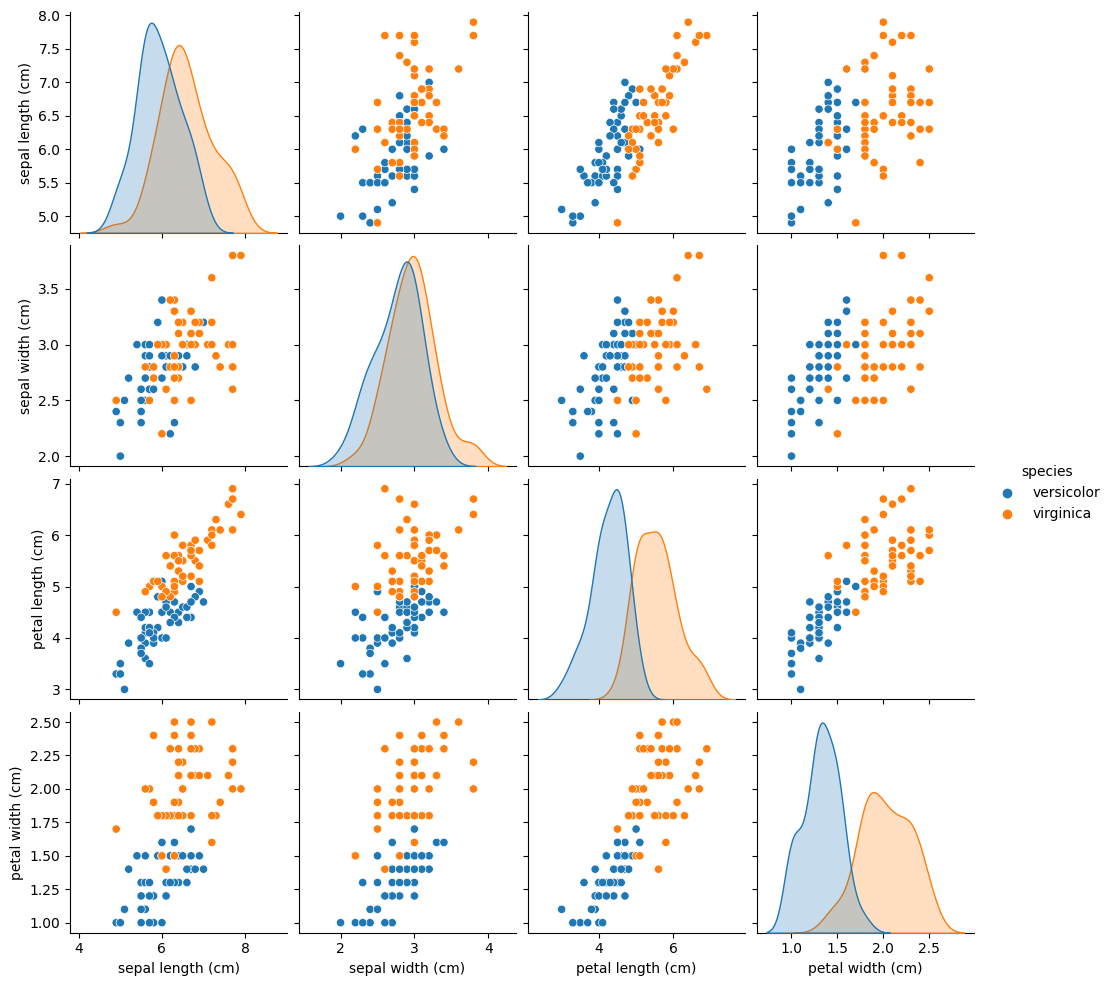

In [17]:
# Load Iris dataset and select 2 classes
iris = datasets.load_iris()
labels = [1, 2]
idx = np.logical_or(iris.target == labels[0], iris.target == labels[1])
iris.data = iris.data[idx, :]
iris.target = iris.target[idx]

# Make a pandas dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target_names[iris.target]

# Plot data
sns.pairplot(df, hue="species")

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
print("Number of features: ", X_train.shape[1])
print("Number of train examples: ", X_train.shape[0])
print("Number of valid examples: ", X_valid.shape[0])


In [18]:
# Converting labels to 0 and 1
y_train_binary = y_train - 1
y_valid_binary = y_valid - 1

w, b = train_lda(X_train, y_train_binary)
y_pred = apply_lda(X_valid, w, b)

accuracy = np.mean(y_pred == y_valid_binary)
print("Accuracy of custom LDA:", accuracy)


lda = LDA()
lda.fit(X_train, y_train_binary)
y_pred_sklearn = lda.predict(X_valid)
accuracy_sklearn = np.mean(y_pred_sklearn == y_valid_binary)
print("Accuracy of sklearn LDA:", accuracy_sklearn)


Accuracy of custom LDA: 0.8
Accuracy of sklearn LDA: 0.8


## Exercise 4: preprocess features
Sometimes, some of the features clearly violate the **linear separability** assumption made by LDA. In that case, features can be pre-processed by applying a given function to each feature, which yields a Generalized Linear Discriminant analysis:

$$ y = \sum_i^D w_i f_i(\mathbf{x}_i) $$ 

We provide a dataset below, please inspect it.

Your tasks:
1. Which LDA assumption(s) are violated by the provided dataset?
1. In which way can the feature(s) be preprocessed in order to improve the performance? Hint: Think of polynomials, trigonometric functions, logarithms, exponential functions, etc.;
1. Apply your preprocessing idea to the data;
1. Visualize the preprocessed data;
1. Classify the preprocessed data using sklearn's `LDA()`. Did it improve?

Accuracy validation: 65.00%


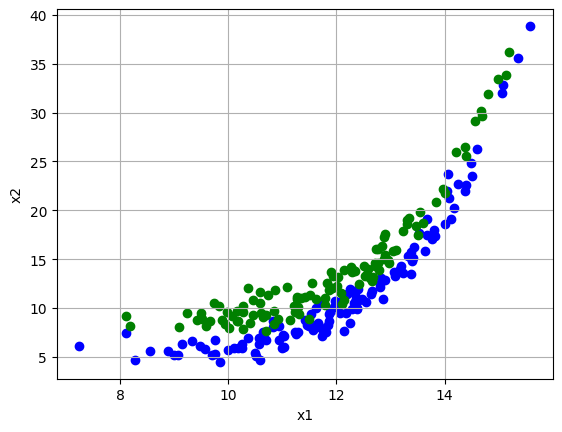

In [25]:
# (1) load data
ds_data = 'data/non-lin_train.data'
ds_labels ='data/non-lin_train.labels'
X = np.loadtxt(ds_data)
y = np.loadtxt(ds_labels)
n_samples = y.size

# (2) split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# (3) scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# (4) classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


1. Какие предположения ЛДА нарушены?
* ЛДА предполагает, что классы разделимы прямой линией.
* Здесь классы, скорее всего, расположены так, что никакая прямая их не разделяет (например, «кольцо» вокруг «точки»).

2. Как можно предобработать признаки?

* Нужно применить нелинейные функции к признакам.
* Примеры:
   * квадраты признаков (x1², x2²),
   * произведение признаков (x1 * x2),
   * тригонометрия (sin(x1), cos(x2)),
    * логарифмы, экспоненты.

В большинстве случаев для таких данных работает добавление квадратичных признаков (x1², x2²).  

3. Применить предобработку
Например:  
X_train_pre = np.column_stack([X_train, X_train[:,0]**2, X_train[:,1]**2])  
X_valid_pre = np.column_stack([X_valid, X_valid[:,0]**2, X_valid[:,1]**2])  

4. Визуализировать преобразованные данные    
Можно построить новый scatter plot, но обычно визуализация ограничена 2D, поэтому лучше смотреть результаты классификации.  

5. Снова обучить LDA и сравнить точность  
clf = LDA()  
clf.fit(X_train_pre, y_train)  
score = clf.score(X_valid_pre, y_valid) * 100  
print('Accuracy validation after preprocessing: {:.2f}%'.format(score))  


Accuracy validation with polynomial preprocessing: 83.33%


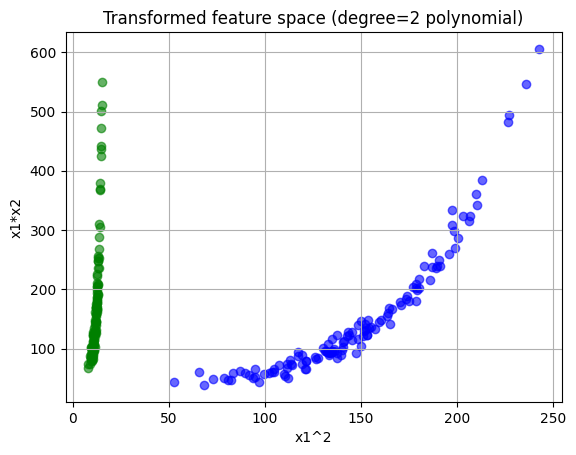

In [27]:
from sklearn.preprocessing import PolynomialFeatures

# (5) Polynomial features for preprocessing
polynomial = PolynomialFeatures(degree=2, include_bias=False)
X_train_polynomial = polynomial.fit_transform(X_train)
X_valid_polynomial = polynomial.transform(X_valid)

# (6) Visualization preprocessed features
plt.figure()
plt.scatter(X_train_polynomial[y_train == 0, 2], X_train_polynomial[y_train == 0, 3], color='b', alpha=0.6)
plt.scatter(X_train_polynomial[y_train == 1, 0], X_train_polynomial[y_train == 1, 3], color='g', alpha=0.6)
plt.xlabel("x1^2")
plt.ylabel("x1*x2")
plt.title("Transformed feature space (degree=2 polynomial)")
plt.grid()

# (7) Classify preprocessed data
clf = LDA()
clf.fit(X_train_polynomial, y_train)
polynomial_score = clf.score(X_valid_polynomial, y_valid) * 100
print('Accuracy validation with polynomial preprocessing: {:.2f}%'.format(polynomial_score))


## (Optional) Exercise 5: extract features
Below we provide another dataset. There appears to be some exploitable structure in this data, but the LDA is not directly able to capture this.

Your tasks:
1. Which LDA assumption(s) are violated by the provided dataset?
1. In what way can the existing features be combined in order to get a proper dataset? **Hint:** Try to think of it in a 3D way: How would you add another dimension such that the 2 classes can be separated?
1. Implement your additional feature that combines the existing features;
1. Visualize the new feature using a histogram;
1. Calculate the performance of LDA using this additional feature and see if you can improve upon the performance.

Accuracy validation: 26.67%


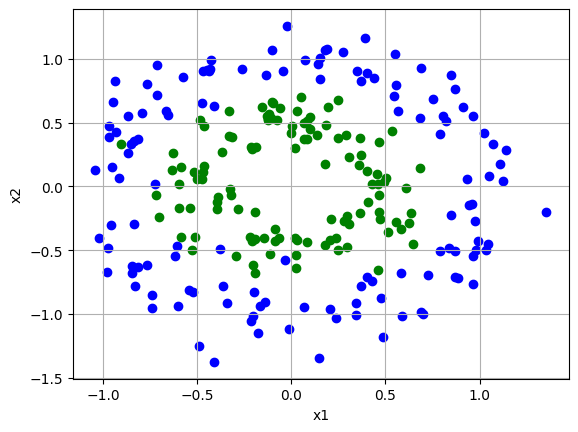

In [28]:
# (1) load data
ds_data = 'data/circles_train.data'
ds_labels ='data/circles_train.labels'
X = np.loadtxt(ds_data)
y = np.loadtxt(ds_labels)
n_samples = len(y)

# (2) split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# (3) scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# (4) classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


1.
* Линейная разделимость / линейное разделение классов — LDA по сути ищет линейную границу (в 2D — прямая). В случае концентрических кругов граница между классами — окружность (нелинейная), поэтому линейный классификатор не справится.
* Гауссовость / одинаковая ковариация (гомоскедастичность) может быть также нарушена: распределения классов вдоль радиуса будут отличаться от нормальных с одинаковой ковариацией.

В итоге — стандартный LDA не может выстроить корректную границу в исходном признаковом пространстве.

2. Если представить точки в 3D, добавив третью ось равной радиусу  (r^2 = x_1 ^2 + x_2 ^2) то классы, которые в 2D лежат в виде концентрических окружностей, в новом пространстве станут разделимы через плоскость по оси r (разделение по порогу r). То есть задача превращается в линейно разделимую в этом 3D-пространстве.
один круг будет выше чем другой, мы можем разделить маленький крцг от большого на высоте от центра (маленький круг ближе по высоте так как меньше расстояние до центар)

3. 

Accuracy (radius only): 95.00%
Accuracy (x1,x2 + radius): 95.00%


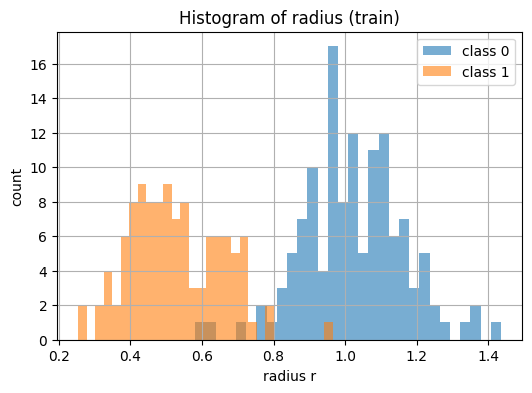

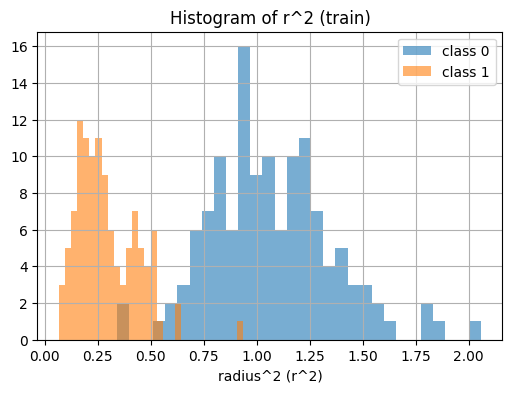

In [29]:
# 1) Построим новый признак: радиус (r) и радиус в квадрате (r2)
r_train = np.sqrt(X_train[:, 0]**2 + X_train[:, 1]**2)
r_valid = np.sqrt(X_valid[:, 0]**2 + X_valid[:, 1]**2)

r2_train = X_train[:, 0]**2 + X_train[:, 1]**2   # альтернатива без sqrt (монотонное)
r2_valid = X_valid[:, 0]**2 + X_valid[:, 1]**2

# ---------------------------
# Вариант A: использовать ТОЛЬКО r (1D-признак)
X_train_r = r_train.reshape(-1, 1)
X_valid_r = r_valid.reshape(-1, 1)

clf_r = LDA()
clf_r.fit(X_train_r, y_train)
score_r = clf_r.score(X_valid_r, y_valid) * 100
print('Accuracy (radius only): {:.2f}%'.format(score_r))

# ---------------------------
# Вариант B: добавить признак r к исходным (расширенное пространство 3D)
X_train_aug = np.column_stack([X_train, r_train])
X_valid_aug = np.column_stack([X_valid, r_valid])

clf_aug = LDA()
clf_aug.fit(X_train_aug, y_train)
score_aug = clf_aug.score(X_valid_aug, y_valid) * 100
print('Accuracy (x1,x2 + radius): {:.2f}%'.format(score_aug))

# ---------------------------
# Визуализация: гистограммы радиуса по классам (train)
plt.figure(figsize=(6,4))
plt.hist(r_train[y_train == 0], bins=30, alpha=0.6, label='class 0')
plt.hist(r_train[y_train == 1], bins=30, alpha=0.6, label='class 1')
plt.xlabel('radius r')
plt.ylabel('count')
plt.title('Histogram of radius (train)')
plt.legend()
plt.grid()
plt.show()

# Опционально: если хотите сравнить r^2
plt.figure(figsize=(6,4))
plt.hist(r2_train[y_train == 0], bins=30, alpha=0.6, label='class 0')
plt.hist(r2_train[y_train == 1], bins=30, alpha=0.6, label='class 1')
plt.xlabel('radius^2 (r^2)')
plt.title('Histogram of r^2 (train)')
plt.legend()
plt.grid()
plt.show()


## (Optional) Exercise 6: other LDA-like algorithms
Below we provide another dataset, that again is problematic for standard LDA.

Your tasks:
1. What LDA assumption(s) are violated by the next dataset?
1. What would be an optimal decision boundary? Optional: Find out which method would provide an optimal decision boundary. **Hint:** It is slightly more general than the LDA algorithm;
1. Implement this improvement and verify whether it indeed improves classification of this dataset.

Accuracy validation: 88.33%


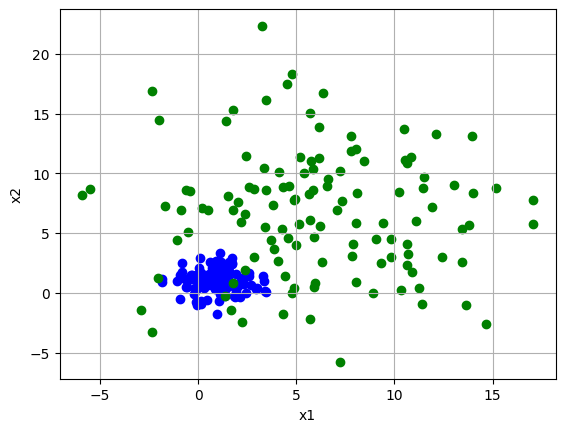

In [30]:
# (1) load data
ds_data = 'data/unbalanced_train.data'
ds_labels ='data/unbalanced_train.labels'
X = np.loadtxt(ds_data)
y = np.loadtxt(ds_labels)
n_samples = len(y)

# (2) split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# (3) scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# (4) classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


1. Какие предположения LDA нарушены
* Нарушено равенство априорных вероятностей классов (несбалансированные классы).
* Гауссовость и линейная разделимость могут быть примерно выполнены, но LDA “игнорирует” дисбаланс, если его явно не учесть.

2. Оптимальная граница решения
* Оптимальная граница должна учитывать априорные вероятности классов (P(C0) и P(C1) ≠ 0.5).
* В sklearn это можно сделать через параметр priors:
LDA(priors=[P0, P1])  
  где P0 и P1 можно задать как частоты классов в тренировочном наборе.
  * Формула LDA с априорными вероятностями:
δk(x)=x^T Σ^−1 μ_k −1/2 μ_k^T Σ^−1 μ_k +log⁡P(C_k)  
    * log P(Ck) сдвигает границу в пользу меньшего класса.  


In [32]:
P0 = np.mean(y_train == 0)
P1 = np.mean(y_train == 1)

clf_balanced = LDA(priors=[P0, P1])
clf_balanced.fit(X_train, y_train)
score_balanced = clf_balanced.score(X_valid, y_valid) * 100
print('Accuracy with priors: {:.2f}%'.format(score_balanced))


Accuracy with priors: 88.33%


## Exercise 7: Apply LDA to EEG data
Now you will try a simple decoding on EEG data. For this, we will make use of one of mne's standard data sets, which you will already know from assignment 1 - but we just load a version resampled to `30Hz`.

The data we load is the so called `raw` data, which we will slice to epochs depending on markers relative to the start of the recording of the raw file. Each epoch should range from -200ms to +800ms around the epoch start marker. Of course you could just make use of `mne`'s build in functions. But for now please operate on the plain numpy array of the raw data. This will ensure, that you are aware of the notion of `epoch` vs `raw` data.

We need this epoch structure as EEG experiments are usually designed to produce one label per epoch. Hence an epoch is our basic "record" unit.

**Question**:
1. Slice the raw data to epochs.
1. After step 1. your data should be in shape of [n_epochs x n_channels x n_times]. The next step is to stack the channel dimension in order to be able to use the data in a standard `sklearn` LDA classifier. Transform the epoched data to [n_epochs x n_channels * n_times]
1. Use the first 100 epochs to train an LDA classifier and report the accuracy of classifying
   the left over epochs as test set.
1. *Optional*: Why will the classifier just perform very poorly in terms of accuracy?

In [34]:
# Prepare data and the classifier
import mne
# the raw data
raw = mne.io.read_raw('./data/sample_audvis_rsampl30Hz_raw.fif')
Xraw = raw.get_data() # shape: [n_channels x n_times_total]

# markers == labels (not always the case that all markers are labels, but its valid here)
mrks = np.load('./data/events.npy', allow_pickle=True) # shape [n_events x 2]
mp = {1: 'left_auditory', 2: 'right_auditory'}
mrks_t = mrks[:, 0] # временные точки событий (в сэмплах) 
y = [mp[e] for e in mrks[:, 1]] # преобразуем метки в 1/2

# the classifier
clf = LDA()

Opening raw data file ./data/sample_audvis_rsampl30Hz_raw.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 60)  idle
    Range : 1289 ... 9619 =     42.967 ...   320.633 secs
Ready.


In [35]:
sfreq = raw.info['sfreq'] #частота дискретизации (сколько сэмплов в секунду, например 30 H
n_channels, n_times = Xraw.shape
print("Number of channels:", n_channels, " Times:", n_times, "Frequency: ", sfreq)

Number of channels: 59  Times: 8331 Frequency:  30.0


Shape of epoched data: (143, 59, 30)
Shape for LDA: (143, 1770)
Accuracy on test set: 48.84%


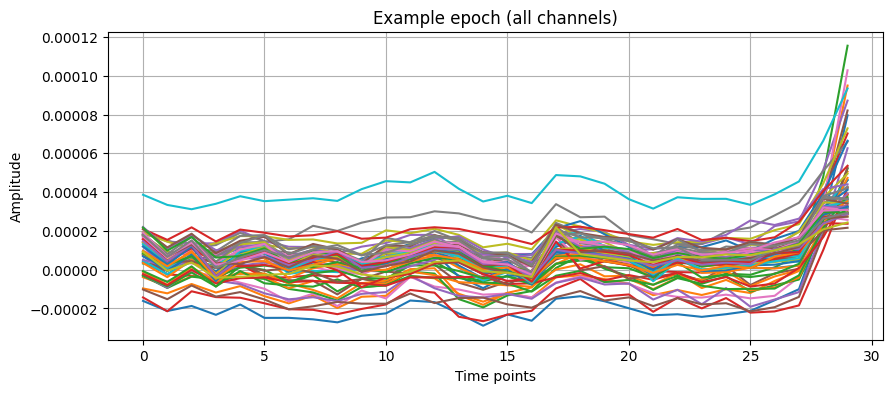

'\nПочему так делаем для EEG:\nЭпохи позволяют анализировать событийно-специфические реакции мозга.\n\nLDA и другие классификаторы работают с плоскими признаками, поэтому нужно «расплющить» каналы и временные точки.\n\nЭто базовый подход в Brain-Computer Interface (BCI) для простого декодирования стимулов.\n'

In [38]:
# --- 3. Нарезка эпох ---
tmin = -0.2  # в секундах
tmax = 0.8   # в секундах
n_channels = Xraw.shape[0] #(каждый канал измеряет активность на определённой точке головы).
n_times = Xraw.shape[1]
    
n_samples_epoch = int((tmax - tmin) * sfreq)  # количество сэмплов в эпох  ==длина сампла  * sfreq)=перевод сек в колво самплов

X_epochs = []  # сюда будем складывать эпохи
valid_labels = []  #список меток для каждой эпохи (какой стимул в этой эпохе).

for i, t in enumerate(mrks_t):   #t — сэмпл события, i — индекс события.
    start = int(t + tmin*sfreq)  #где начинать брать сэмплы (относительно события).
    end   = int(t + tmax*sfreq)
    # проверка выхода за границы
    if start >= 0 and end <= n_times: #ногда событие близко к началу или концу записи, и эпоха «вылезает» за массив → такие события пропускаем.
        epoch = Xraw[:, start:end]  # shape [n_channels x n_times_epoch]  берём все каналы для нужного временного окна.
        X_epochs.append(epoch)
        valid_labels.append(y[i])

X_epochs = np.array(X_epochs)          # shape [n_epochs x n_channels x n_times]  Превращаем список эпох в numpy-массив.
y_epochs = np.array(valid_labels)    #метки для каждой эпохи
print("Shape of epoched data:", X_epochs.shape)
#Смысл для EEG: каждая эпоха теперь представляет кусок мозга вокруг события, на котором мы хотим классифицировать стимул.


# --- 4. Преобразование в 2D для LDA ---
n_epochs, n_channels, n_times = X_epochs.shape
X_flat = X_epochs.reshape(n_epochs, n_channels*n_times) #eshape превращает каждую эпоху в плоский вектор, объединяя каналы и время:
print("Shape for LDA:", X_flat.shape)
#Каждая строка — эпоха, каждая колонка — признак (сигнал в конкретном канале и времени).



# --- 5. Train-test split ---
X_train = X_flat[:100]
y_train = y_epochs[:100]
X_test  = X_flat[100:]
y_test  = y_epochs[100:]

# --- 6. Обучение LDA ---
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_test, y_test) * 100  #проверяем точность на тесте.
print("Accuracy on test set: {:.2f}%".format(score))

"""
Смысл для EEG:
LDA пытается найти линейную комбинацию всех каналов и временных точек, которая лучше всего разделяет стимулы left_auditory и right_auditory.

Ограничение: прямое использование всех каналов + временных точек как фичей почти всегда приводит к низкой точности, потому что:
EEG шумный, слабый сигнал;
Игнорируются временные закономерности (например, ERP компоненты).
"""

# --- 7. Визуализация одной эпохи ---
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(X_epochs[0].T)  # все каналы первой эпохи
plt.title("Example epoch (all channels)")
plt.xlabel("Time points")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


"""
Почему так делаем для EEG:
Эпохи позволяют анализировать событийно-специфические реакции мозга.

LDA и другие классификаторы работают с плоскими признаками, поэтому нужно «расплющить» каналы и временные точки.

Это базовый подход в Brain-Computer Interface (BCI) для простого декодирования стимулов.
"""

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here